# Conditional 3D prediction

Generate one categorical `64³` volume that satisfies multiple anchors on arbitrary axes, follows an explicit phase-fraction condition, and remains natural in every XY/XZ/YZ slice.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.api import AnchorSlice, PredictOptions
from src.app.runtime import (
    build_dataset,
    build_loader,
    load_defaults,
    load_predictor,
    load_slicegan_config,
)
from src.modeling.phases import quantize_phase

def take_slice(volume, axis, index):
    return np.take(volume, index, axis=axis)


## Parameters

The default example places the same compatible categorical condition on the center XY and XZ planes. Change each `AnchorSlice` independently when supplying compatible cross-sections.

In [2]:
RUN_DIR = 'run/20260712-163751-714469'
PHASE_FRACTIONS = (0.28, 0.12, 0.60)
slicegan_config = load_slicegan_config(ROOT / 'config' / 'slicegan.yaml')

options_kwargs = dict(
    slicegan=slicegan_config,
    phase_fractions=PHASE_FRACTIONS,
)


## Predict

In [3]:
run_dir = ROOT / RUN_DIR
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = Namespace(**load_defaults(run_dir / 'vae.yaml'))
args.data_dir = ROOT / args.data_dir
args.batch_size = 1

batch = next(build_loader(build_dataset(args), args, device=torch.device('cpu')))
anchor_image = quantize_phase(batch[0, 0], args.num_phases).numpy()
center_index = anchor_image.shape[0] // 2
anchors = [
    AnchorSlice(image=anchor_image, axis=0, index=center_index),
    AnchorSlice(image=anchor_image.copy(), axis=1, index=center_index),
]
options = PredictOptions(num_phases=args.num_phases, **options_kwargs)

predictor = load_predictor(run_dir, device=device)
start_time = time.perf_counter()
volume, stats = predictor.predict(options, anchors=anchors)
elapsed_seconds = time.perf_counter() - start_time
volume_np = volume.cpu().numpy()

print('device:', device)
print(f'elapsed: {elapsed_seconds:.1f} seconds')
print('volume:', volume_np.shape, volume.dtype)
print('anchors:', [(anchor.axis, anchor.index) for anchor in anchors])
print('selected training step:', int(stats['slicegan_selected_step']))
print('condition candidates checked:', int(stats['slicegan_condition_candidates']))
print('anchor mismatches:', np.round(stats['slicegan_anchor_mismatches'].cpu().numpy(), 4).tolist())
print('target phase fraction:', np.round(stats['slicegan_target_phase_fraction'].cpu().numpy(), 4).tolist())
print('volume phase fraction:', np.round(stats['slicegan_phase_fraction'].cpu().numpy(), 4).tolist())


device: cuda
elapsed: 758.2 seconds
volume: (64, 64, 64) torch.uint8
anchors: [(0, 32), (1, 32)]
selected training step: 6000
condition candidates checked: 3
anchor mismatches: [0.08079999685287476, 0.07980000227689743]
target phase fraction: [0.2800000011920929, 0.11999999731779099, 0.6000000238418579]
volume phase fraction: [0.2800000011920929, 0.11999999731779099, 0.6000000238418579]


## Quality check

Each anchor should be similar but not copied. The explicit phase fractions should be within ±1 percentage point, and no axis should show a cutoff immediately outside the anchor neighborhood.

anchor mismatches: [0.0808, 0.0798]
target phase fraction: [0.28, 0.12, 0.6]
volume phase fraction: [0.28, 0.12, 0.6]
axis transition rate: [0.2207, 0.2226, 0.2094]
axis=0, index=32, ±6 boundary: [0.2197, 0.2307, 0.2395, 0.2095, 0.22, 0.2163, 0.2446, 0.2214, 0.2271, 0.2283, 0.2349, 0.1997] max jump: 0.0352
axis=1, index=32, ±6 boundary: [0.2144, 0.2388, 0.2449, 0.241, 0.2334, 0.2217, 0.2253, 0.2058, 0.2368, 0.24, 0.2495, 0.207] max jump: 0.0425
quality gates: {'all anchors 3-10% different': True, 'phase fraction within 1%p': True, 'axis transition spread <= 0.03': True, 'local boundary jump <= 0.08': True}


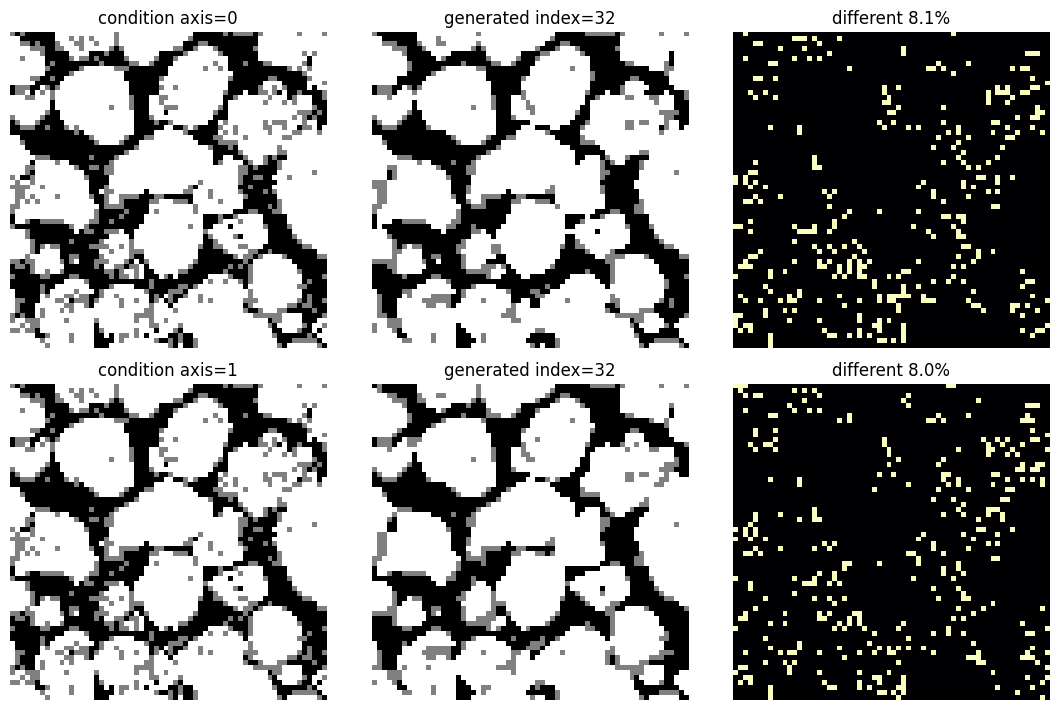

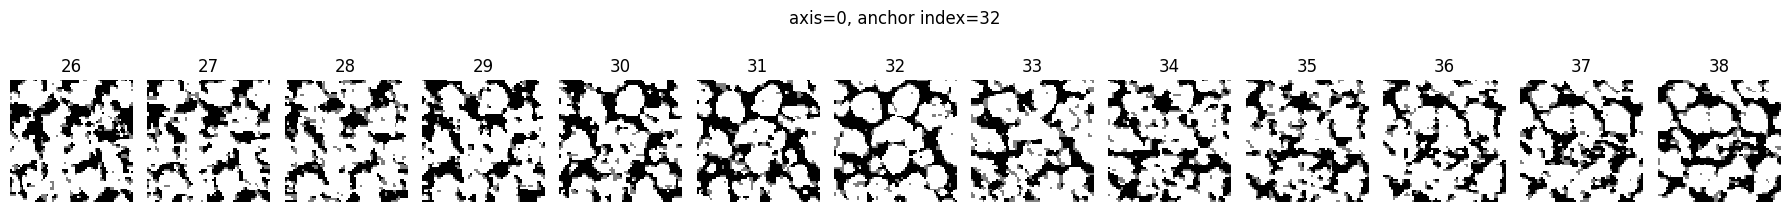

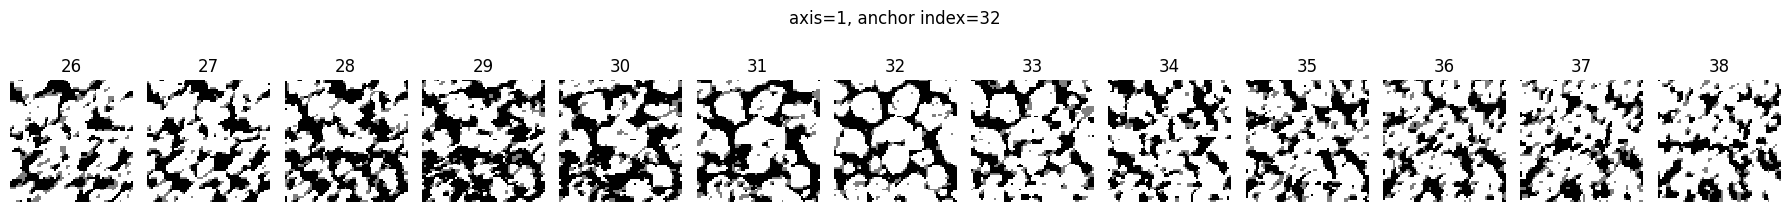

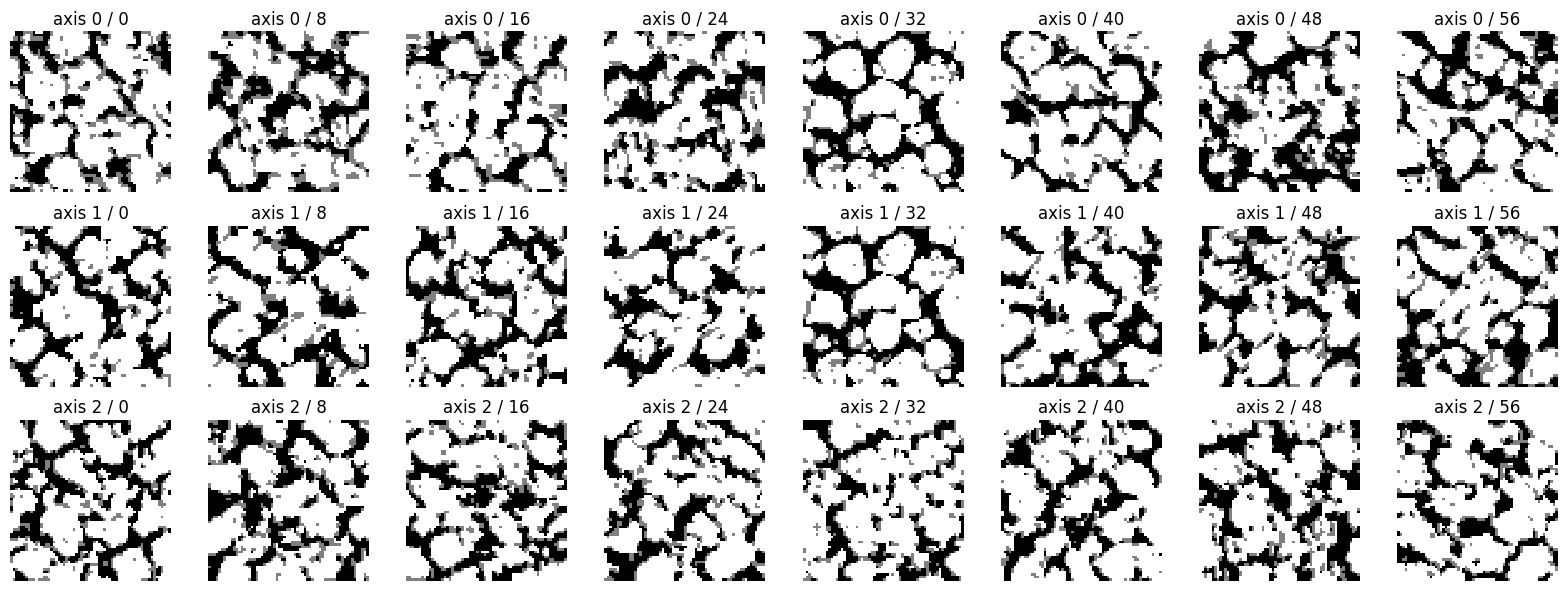

In [4]:
anchor_mismatches = np.array([
    np.mean(take_slice(volume_np, anchor.axis, anchor.index) != anchor.image)
    for anchor in anchors
])
volume_phase_fraction = np.array([
    np.mean(volume_np == phase) for phase in range(args.num_phases)
])
axis_transition_rate = np.array([
    np.mean(np.diff(volume_np, axis=axis) != 0) for axis in range(3)
])

boundary_profiles = []
boundary_jumps = []
for anchor in anchors:
    differences = np.diff(volume_np, axis=anchor.axis) != 0
    reduce_axes = tuple(axis for axis in range(3) if axis != anchor.axis)
    rates = differences.mean(axis=reduce_axes)
    local = rates[anchor.index - 6 : anchor.index + 6]
    boundary_profiles.append(local)
    boundary_jumps.append(np.max(np.abs(np.diff(local))))

quality_gates = {
    'all anchors 3-10% different': bool(np.all((anchor_mismatches >= 0.03) & (anchor_mismatches <= 0.10))),
    'phase fraction within 1%p': bool(np.max(np.abs(volume_phase_fraction - PHASE_FRACTIONS)) <= 0.01),
    'axis transition spread <= 0.03': bool(np.ptp(axis_transition_rate) <= 0.03),
    'local boundary jump <= 0.08': bool(max(boundary_jumps) <= 0.08),
}
print('anchor mismatches:', np.round(anchor_mismatches, 4).tolist())
print('target phase fraction:', list(PHASE_FRACTIONS))
print('volume phase fraction:', np.round(volume_phase_fraction, 4).tolist())
print('axis transition rate:', np.round(axis_transition_rate, 4).tolist())
for anchor, profile, jump in zip(anchors, boundary_profiles, boundary_jumps):
    print(f'axis={anchor.axis}, index={anchor.index}, ±6 boundary:', np.round(profile, 4).tolist(), 'max jump:', round(float(jump), 4))
print('quality gates:', quality_gates)

fig, axes = plt.subplots(len(anchors), 3, figsize=(11, 3.6 * len(anchors)), squeeze=False)
for row, anchor in enumerate(anchors):
    generated = take_slice(volume_np, anchor.axis, anchor.index)
    difference = generated != anchor.image
    items = [
        (anchor.image, f'condition axis={anchor.axis}', 'gray', 0, args.num_phases - 1),
        (generated, f'generated index={anchor.index}', 'gray', 0, args.num_phases - 1),
        (difference, f'different {anchor_mismatches[row]:.1%}', 'magma', 0, 1),
    ]
    for axis, (image, title, cmap, vmin, vmax) in zip(axes[row], items):
        axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        axis.set_title(title)
        axis.axis('off')
plt.tight_layout()

for anchor in anchors:
    offsets = range(-6, 7)
    fig, axes = plt.subplots(1, len(offsets), figsize=(18, 2.4))
    for axis, offset in zip(axes, offsets):
        index = anchor.index + offset
        axis.imshow(take_slice(volume_np, anchor.axis, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axis.set_title(f'{index}')
        axis.axis('off')
    fig.suptitle(f'axis={anchor.axis}, anchor index={anchor.index}')
    plt.tight_layout()

indices = range(0, volume_np.shape[0], 8)
fig, axes = plt.subplots(3, len(indices), figsize=(16, 6))
for row, axis_id in enumerate(range(3)):
    for column, index in enumerate(indices):
        axes[row, column].imshow(take_slice(volume_np, axis_id, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axes[row, column].set_title(f'axis {axis_id} / {index}')
        axes[row, column].axis('off')
plt.tight_layout()


## 3D slice browser

Choose an axis and move the slider to inspect every generated slice.

In [5]:
axis_selector = widgets.ToggleButtons(options=[('XY', 0), ('XZ', 1), ('YZ', 2)], value=0, description='axis')
index_slider = widgets.IntSlider(value=volume_np.shape[0] // 2, min=0, max=volume_np.shape[0] - 1, step=1, description='index', continuous_update=False)

def show_slice(axis, index):
    plt.figure(figsize=(5, 5))
    plt.imshow(take_slice(volume_np, axis, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
    plt.title(f'axis {axis} · index {index}')
    plt.axis('off')
    plt.show()

slice_output = widgets.interactive_output(show_slice, {'axis': axis_selector, 'index': index_slider})
display(widgets.HBox([axis_selector, index_slider]), slice_output)


Output()